# 🎓 Student Lifestyle Analysis

This notebook explores how students' daily habits — sleep, study, social activity, and physical exercise — relate to their **stress levels** and **academic performance (GPA)**.

Two datasets are combined:
- **Student lifestyle dataset** — daily hours, GPA, stress level
- **US demographic dataset** — real names, age, city

The analysis covers data cleaning, exploratory analysis, correlation heatmaps, and a machine learning classifier to predict stress level.

In [59]:
# Import necessary libraries for data analysis and visualization
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [60]:
# Ensure the results/plots folder exists
os.makedirs("results/plots", exist_ok=True)

In [61]:
# Load datasets from CSV files
df_lifestyle = pd.read_csv("data/student_lifestyle_dataset.csv")
df_realnames = pd.read_csv("data/us_dataset_real_names.csv")

In [62]:
# Remove duplicate rows from both datasets
df_lifestyle = df_lifestyle.drop_duplicates()
df_realnames = df_realnames.drop_duplicates()

In [63]:
# Data cleaning and preprocessing for student lifestyle dataset
# Convert relevant columns to numeric format to handle invalid or missing values
df_lifestyle["Sleep_Hours_Per_Day"] = pd.to_numeric(df_lifestyle["Sleep_Hours_Per_Day"], errors="coerce")
df_lifestyle["Social_Hours_Per_Day"] = pd.to_numeric(df_lifestyle["Social_Hours_Per_Day"], errors="coerce")

# Define stress levels as ordered categories: Low < Moderate < High
# This maintains logical ordering and prevents incorrect comparisons
stress_order = pd.CategoricalDtype(categories = ["Low", "Moderate", "High"], ordered = True)
df_lifestyle["Stress_Level"] = df_lifestyle["Stress_Level"].astype(stress_order)
df_lifestyle["Stress_Level_Numeric"] = df_lifestyle["Stress_Level"].cat.codes

# Handle invalid GPA values (outside range [0, 4])
# Replace out-of-range GPA with the mean of valid GPA values
valid_gpa_mask = (df_lifestyle["GPA"] >= 0) & (df_lifestyle["GPA"] <= 4)
mean_gpa = df_lifestyle.loc[valid_gpa_mask, "GPA"].mean().round(2)
df_lifestyle.loc[~valid_gpa_mask, "GPA"] = mean_gpa

# Identify all columns representing hours per day (Sleep_Hours_Per_Day, Social_Hours_Per_Day, etc.)
hour_cols = [col for col in df_lifestyle.columns if "Hours_Per_Day" in col]

# Clean invalid hour values (NaN, negative, or > 24)
# Distribute remaining time in the day equally among invalid entries
bad_mask = (df_lifestyle[hour_cols].isna()) | (df_lifestyle[hour_cols] < 0) | (df_lifestyle[hour_cols] > 24)
valid_sums = df_lifestyle[hour_cols].where(~bad_mask, 0).sum(axis=1)
remaining_time = (24 - valid_sums).clip(lower=0)
bad_counts = bad_mask.sum(axis=1)
fill_values = remaining_time.div(bad_counts).replace([np.inf, -np.inf], 0)
df_lifestyle[hour_cols] = df_lifestyle[hour_cols].mask(bad_mask, fill_values, axis=0)

In [64]:
# Convert columns in the real names dataset to appropriate data types
# String types for names and categorical type for city to optimize memory usage
df_realnames["first_name"] = df_realnames["first_name"].astype(str)
df_realnames["last_name"] = df_realnames["last_name"].astype(str)
df_realnames["city"] = df_realnames["city"].astype("category")

In [65]:
# Merge demographic data with lifestyle data using inner join on student ID
df_realnames_lifestyle = df_realnames.merge(df_lifestyle, how="inner", left_on="id", right_on="Student_ID")

## 📊 Exploratory Analysis

In [66]:
# Find and display the age of the youngest student in the dataset
youngest_student = df_realnames_lifestyle["age"].min()
print(f"The age of the youngest student is {youngest_student} years old.")

The age of the youngest student is 21 years old.


In [67]:
# Calculate average GPA grouped by city and display in descending order
# Group by city, compute mean GPA, round to 2 decimal places, and sort by highest average GPA first
average_gpa_city = df_realnames_lifestyle.groupby("city", observed=False)["GPA"].mean().round(2).reset_index(name="Mean_GPA").rename(columns={"city": "City"}).sort_values("Mean_GPA", ascending=False)
average_gpa_city.index = range(1, len(average_gpa_city) + 1)
print(f"The average GPA by city is: \n{average_gpa_city}")

The average GPA by city is: 
          City  Mean_GPA
1      Chicago      3.13
2      Phoenix      3.12
3  Los Angeles      3.11
4     New York      3.11
5      Houston      3.10


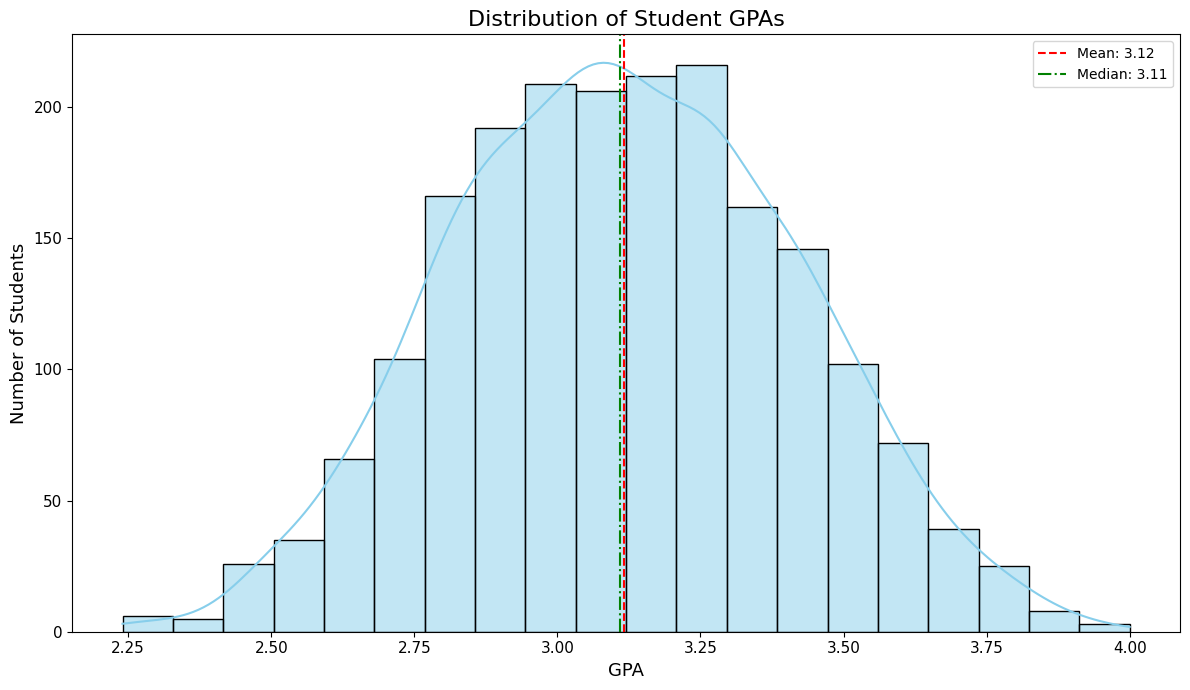

In [68]:
# Plot GPA histogram to show the distribution between students and save it as .jpg 
plt.figure(figsize=(12, 7))
sns.histplot(data=df_realnames_lifestyle, x="GPA", bins=20, kde=True, color="skyblue", edgecolor="black")
plt.axvline(df_realnames_lifestyle["GPA"].mean(), color='red', linestyle='--', label=f"Mean: {df_realnames_lifestyle['GPA'].mean():.2f}")
plt.axvline(df_realnames_lifestyle["GPA"].median(), color='green', linestyle='-.', label=f"Median: {df_realnames_lifestyle['GPA'].median():.2f}")
plt.title("Distribution of Student GPAs", fontsize=16)
plt.xlabel("GPA", fontsize=13)
plt.ylabel("Number of Students", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/histogram_gpa.jpg", format='jpg')
plt.show()

### 📈 GPA Distribution

> **Finding:** The GPA distribution is approximately **normal** (skew ≈ 0.03), with a mean of **3.12** and a median of **3.11**. The near-identical mean and median confirm the distribution is well-balanced with no significant outliers pulling it in either direction. Most students cluster around a solid B+ average.

In [69]:
# Function to create a single correlation heatmap and save the image as .jpg if wanted
def plot_hours_vs_stress_heatmap(data, hours_col, title, filename, cmap='YlGnBu'):
    """
    This function creates a heatmap showing the relationship between a selected Hours_Per_Day column and Stress_Level, and saves it as a .jpg image.

    data: DataFrame – the source data
    hours_col: str – column for the y-axis (e.g., 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', etc.)
    title: str – title of the plot
    filename: str – name of the file to save as .jpg (e.g., "heatmap1.jpg")
    cmap: str – color map for the heatmap (default 'YlGnBu')

    Returns nothing, just saves the image and shows the plot.
    """
    corr_matrix = data[[hours_col, "Stress_Level_Numeric"]].corr()

    # Shorten axis labels for readability
    label_map = {hours_col: hours_col.replace("_Hours_Per_Day", "").replace("_", " "), "Stress_Level_Numeric": "Stress Level"}
    corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

    plt.figure(figsize=(12, 7))
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        linecolor='black',
        cbar_kws={'label': 'Correlation Coefficient'}
    )

    plt.title(title, fontsize=16)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.savefig(f"results/plots/{filename}", format='jpg')
    plt.show()

## 🔥 Correlation Analysis

The heatmaps below show how each daily activity correlates with stress level.
A value close to **-1** means more hours → lower stress, close to **+1** means more hours → higher stress.

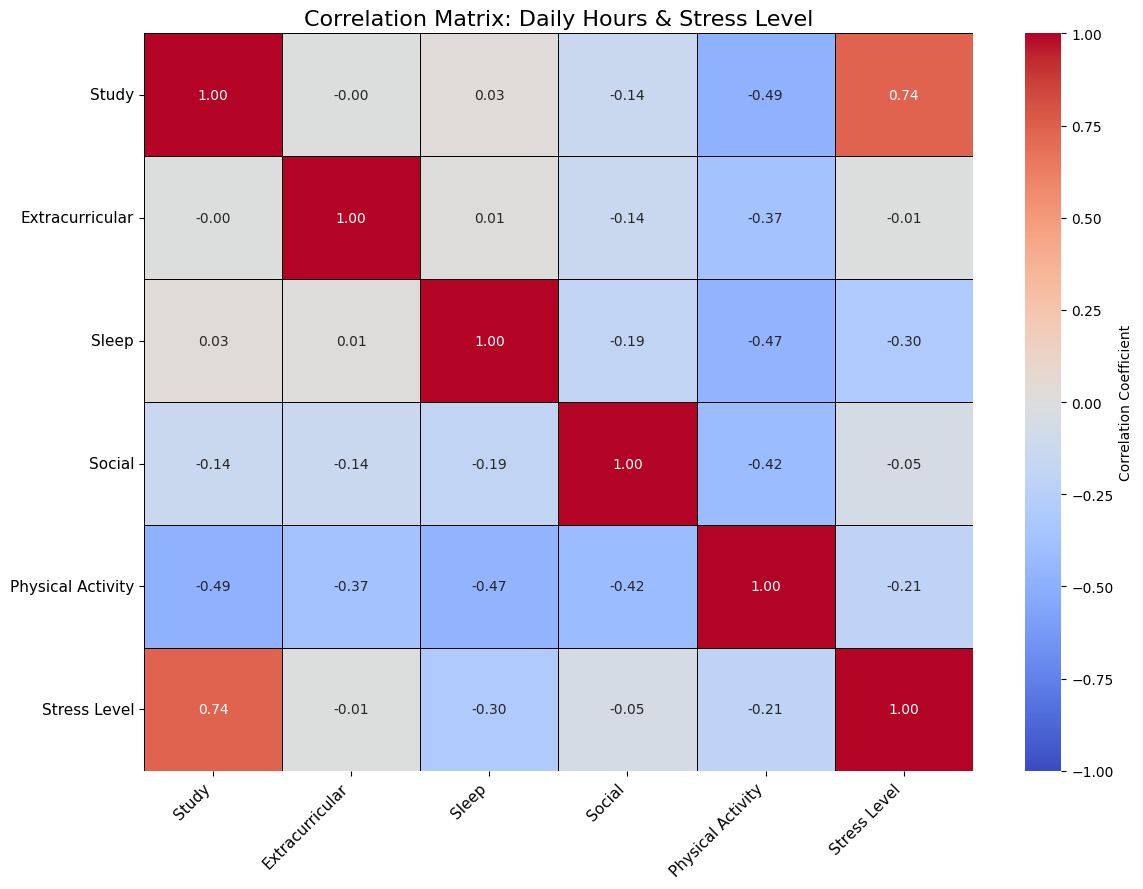

In [70]:
# Combined heatmap showing correlations between all Hours_Per_Day columns and Stress Level
cols_of_interest = hour_cols + ["Stress_Level_Numeric"]
corr_matrix = df_realnames_lifestyle[cols_of_interest].corr()

# Shorten axis labels for readability
label_map = {col: col.replace("_Hours_Per_Day", "").replace("_", " ") for col in hour_cols}
label_map["Stress_Level_Numeric"] = "Stress Level"
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Correlation Coefficient"},
)
plt.title("Correlation Matrix: Daily Hours & Stress Level", fontsize=16)
plt.xticks(fontsize=11, rotation=45, ha="right")
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig("results/plots/heatmap_combined.jpg", format="jpg")
plt.show()

### 🗺️ Combined Correlation Matrix

> **Finding:** Study hours show the strongest **positive** correlation with stress (r = **+0.74**), meaning students who study more tend to report significantly higher stress. Sleep and physical activity show negative correlations (r = **-0.30** and **-0.21** respectively), suggesting these are protective factors. Social and extracurricular hours have almost no relationship with stress (r ≈ 0.00).

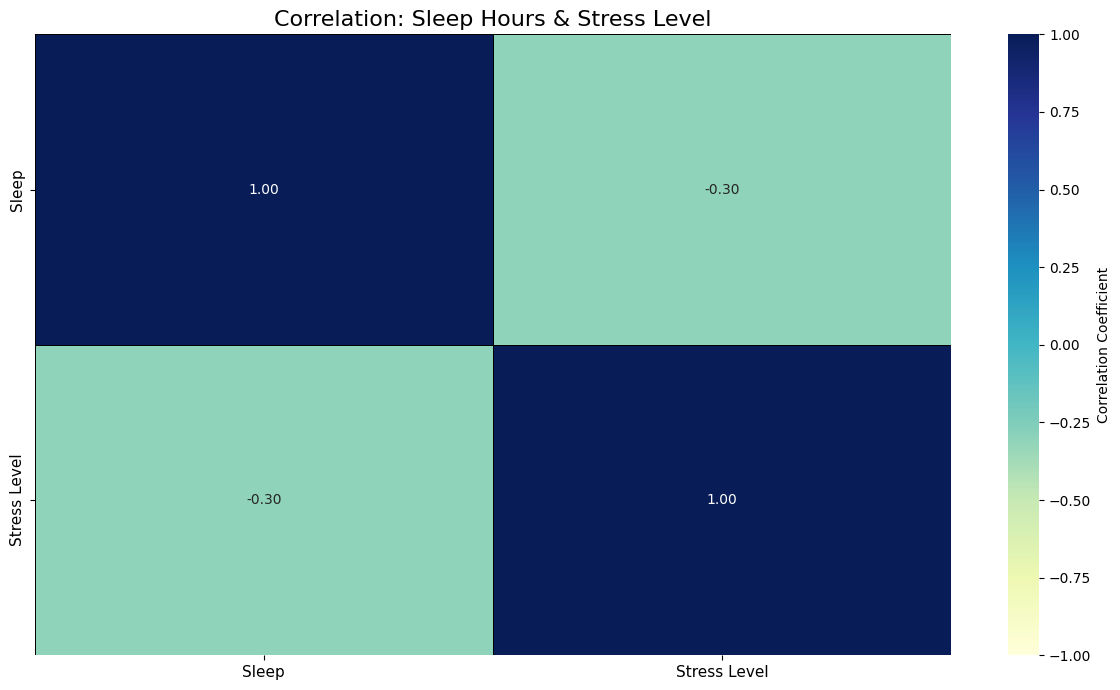

In [71]:
# Highlight the correlation between sleep hours and stress level
plot_hours_vs_stress_heatmap(
    df_realnames_lifestyle,
    "Sleep_Hours_Per_Day",
    "Correlation: Sleep Hours & Stress Level",
    "heatmap_sleep.jpg"
)

### 😴 Sleep Hours vs Stress Level

> **Finding:** Sleep hours have a clear **negative** correlation with stress (r = **-0.30**), confirming that students who sleep less tend to experience higher stress levels. While not the strongest predictor on its own, sleep is the most impactful **protective** factor against stress in this dataset.

In [72]:
# Machine learning imports for training and evaluating a stress level classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Define target features and target variable
features = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "GPA"
]
X = df_realnames_lifestyle[features]
y = df_realnames_lifestyle["Stress_Level_Numeric"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        67
    Moderate       1.00      1.00      1.00       127
        High       1.00      1.00      1.00       206

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [73]:
# Import of Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Training Logistic Regression model
logisticRegr = LogisticRegression(max_iter=150)
logisticRegr.fit(X_train, y_train)

# Evaluate on test set
log_y_pred = logisticRegr.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, log_y_pred):.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, log_y_pred, target_names=["Low", "Moderate", "High"]))

Model Accuracy: 85.00%

Classification Report:
              precision    recall  f1-score   support

         Low       0.84      0.91      0.87        67
    Moderate       0.82      0.73      0.78       127
        High       0.87      0.90      0.89       206

    accuracy                           0.85       400
   macro avg       0.84      0.85      0.84       400
weighted avg       0.85      0.85      0.85       400



### 🔁 Cross-Validation (5-Fold)

To evaluate model stability beyond a single train/test split, we use stratified 5-fold cross-validation on both models using the same features and target.

In [74]:
# Cross-validation comparison for Random Forest and Logistic Regression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

log_cv_scores = cross_val_score(
    LogisticRegression(max_iter=150),
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

print("Cross-Validation Accuracy (5-fold):")
print(f"Random Forest       : {rf_cv_scores.mean():.2%} ± {rf_cv_scores.std():.2%}")
print(f"Logistic Regression : {log_cv_scores.mean():.2%} ± {log_cv_scores.std():.2%}")

Cross-Validation Accuracy (5-fold):
Random Forest       : 100.00% ± 0.00%
Logistic Regression : 82.30% ± 1.58%


## 🤖 Machine Learning — Model Comparison

In this section, two classifiers are trained to predict student stress level (Low / Moderate / High):
- **Random Forest Classifier**
- **Logistic Regression**

Both models use the same train/test split and the same input features.

| Setting | Value |
|---|---|
| Features | Study, Extracurricular, Sleep, Social, Physical Activity, GPA |
| Train / Test split | 80% / 20% |
| Random state | 42 |
| Random Forest | `n_estimators=100` |
| Logistic Regression | `max_iter=150` |

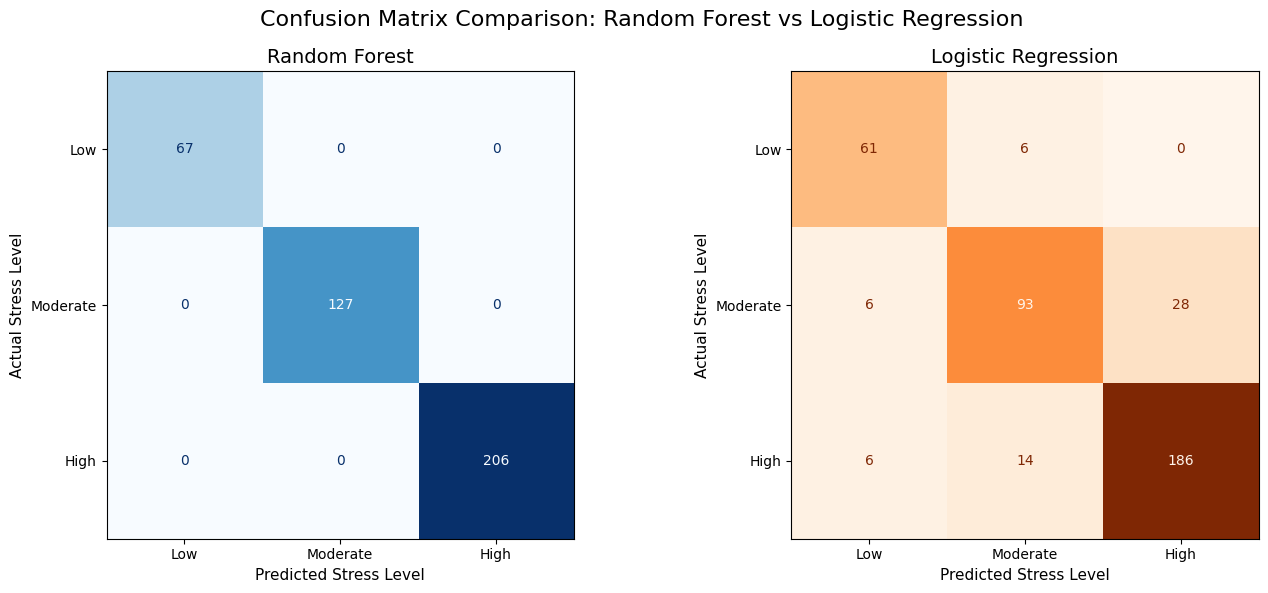

In [75]:
# Plot side-by-side confusion matrices to compare Random Forest vs Logistic Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ["Low", "Moderate", "High"]
cm_rf = confusion_matrix(y_test, y_pred)
cm_log = confusion_matrix(y_test, log_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names).plot(
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Random Forest", fontsize=14)
axes[0].set_xlabel("Predicted Stress Level", fontsize=11)
axes[0].set_ylabel("Actual Stress Level", fontsize=11)

ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=class_names).plot(
    cmap="Oranges", ax=axes[1], colorbar=False
)
axes[1].set_title("Logistic Regression", fontsize=14)
axes[1].set_xlabel("Predicted Stress Level", fontsize=11)
axes[1].set_ylabel("Actual Stress Level", fontsize=11)

plt.suptitle("Confusion Matrix Comparison: Random Forest vs Logistic Regression", fontsize=16)
plt.tight_layout()
plt.savefig("results/plots/confusion_matrix_comparison.jpg", format="jpg")
plt.show()

### 📋 Model Performance Comparison

> **Finding:** Random Forest achieved **100.00%** accuracy, while Logistic Regression reached **85.00%** on the same 400 test samples. Logistic Regression performs reasonably well overall, but it struggles most on the **Moderate** class (recall = 0.73), where class boundaries likely overlap more. In contrast, Random Forest separates all three classes perfectly in this dataset.

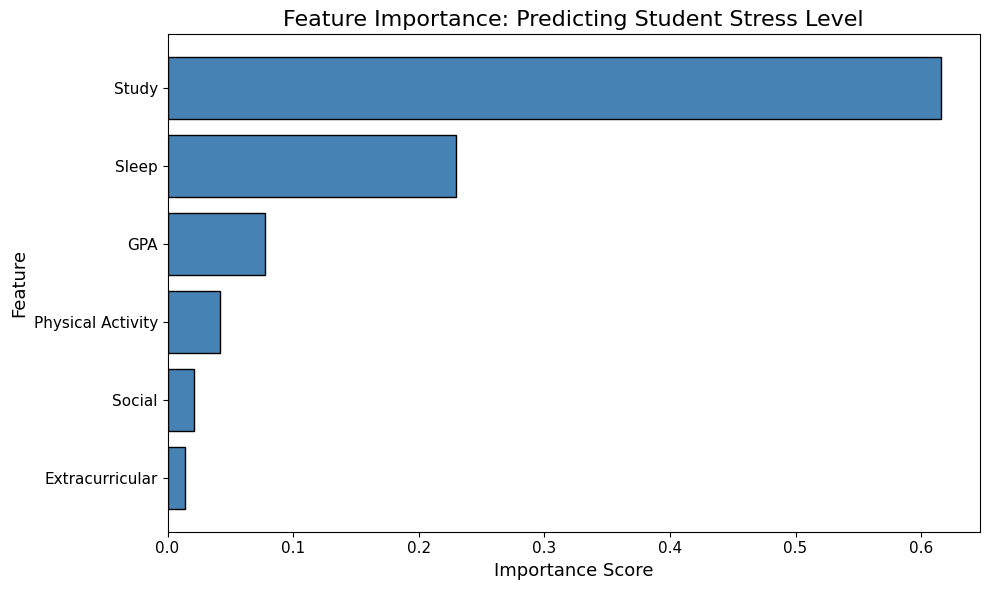

In [76]:
# Plot feature importances to show which lifestyle factors most influence stress level prediction
feature_labels = [f.replace("_Hours_Per_Day", "").replace("_", " ") for f in features]
importances = model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color="steelblue",
    edgecolor="black",
)
plt.title("Feature Importance: Predicting Student Stress Level", fontsize=16)
plt.xlabel("Importance Score", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig("results/plots/feature_importance.jpg", format="jpg")
plt.show()

### 🏆 Feature Importance

> **Finding:** **Study hours** is by far the most predictive feature (importance = **0.616**), accounting for over 60% of the model's decisions. **Sleep hours** is the second most important (0.230), followed by GPA (0.077) and physical activity (0.042). Social and extracurricular hours contribute the least (< 0.02 each).

---

## ✅ Conclusions

1. **Academic workload is the dominant driver of stress.** Study hours show the strongest positive correlation with stress (r = +0.74) and are the most influential feature in Random Forest.
2. **Lifestyle recovery factors matter.** Sleep (r = -0.30) and physical activity (r = -0.21) are negatively correlated with stress, suggesting a protective effect.
3. **Random Forest outperformed Logistic Regression** in this task (**100% vs 85% accuracy**), which indicates non-linear patterns in the data and/or strongly structured (likely synthetic) class boundaries.